# Laboratorio 7 — Spark MLlib
## ENEIC: perfiles de trabajadores asalariados y estimación del salario mensual


In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.stat import Correlation
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.sql.window import Window
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

spark = (
    SparkSession.builder
    .appName("laboratorio7_eneic")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark

26/09/24 23:08:02 WARN Utils: Your hostname, vm resolves to a loopback address: 127.0.0.1; using 192.0.2.2 instead (on interface eth0)
26/09/24 23:08:02 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/24 23:08:03 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 1. Carga, armonización y calidad de datos (5 pts)

Se parte de los Parquet generados por `preparar_datos.py`: uno por cada trimestre de 2025, ya
unidos con `unionByName`, y uno para 2026T1 (reservado para la evaluación final). La unión por
nombre es necesaria porque **2025-IV no comparte el mismo orden de columnas** que los otros tres
archivos — apilar por posición mezclaría variables distintas bajo el mismo nombre de columna.

In [2]:
import os

df_2025 = spark.read.parquet("../data/processed/eneic_2025.parquet")

_ruta_2026 = "../data/processed/eneic_2026.parquet"
HAY_2026 = os.path.exists(_ruta_2026)
df_2026 = spark.read.parquet(_ruta_2026) if HAY_2026 else None
if not HAY_2026:
    print("AVISO: 2026T1 (evaluacion final) todavia no esta disponible -- se omite en este avance.")

df_2025.printSchema()
df_2025.select(
    "periodo_archivo", "num_hogar", "num_persona", "edad", "antiguedad",
    "horas_semanales", "nivel_educativo", "p05c16", "dominio", "p05d01",
).show(5, truncate=False)


[Stage 0:>                                                          (0 + 1) / 1]



AVISO: 2026T1 (evaluacion final) todavia no esta disponible -- se omite en este avance.
root
 |-- num_hogar: string (nullable = true)
 |-- num_persona: string (nullable = true)
 |-- trimestre_original: string (nullable = true)
 |-- ocupados: string (nullable = true)
 |-- p05c16: string (nullable = true)
 |-- p05d01: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- dominio: string (nullable = true)
 |-- factor: double (nullable = true)
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- antiguedad: double (nullable = true)




[Stage 1:>                                                          (0 + 1) / 1]



+---------------+---------+-----------+----+----------+---------------+---------------+------+-------+------+
|periodo_archivo|num_hogar|num_persona|edad|antiguedad|horas_semanales|nivel_educativo|p05c16|dominio|p05d01|
+---------------+---------+-----------+----+----------+---------------+---------------+------+-------+------+
|2025T1         |13796    |3          |14.0|NULL      |NULL           |3              |NULL  |2      |NULL  |
|2025T1         |13796    |1          |42.0|23.0      |35.0           |5              |6     |2      |NULL  |
|2025T1         |13796    |2          |42.0|20.0      |1.0            |5              |1     |2      |7000.0|
|2025T1         |13796    |5          |9.0 |NULL      |NULL           |2              |NULL  |2      |NULL  |
|2025T1         |13796    |4          |11.0|NULL      |NULL           |2              |NULL  |2      |NULL  |
+---------------+---------+-----------+----+----------+---------------+---------------+------+-------+------+
only showi

**Registros por archivo, antes de cualquier filtro:**

In [3]:
conteo_por_archivo = (
    df_2025.groupBy("periodo_archivo")
    .count()
    .orderBy("periodo_archivo")
)
conteo_por_archivo.show()

+---------------+-----+
|periodo_archivo|count|
+---------------+-----+
|         2025T1|51588|
|         2025T2|51167|
+---------------+-----+



**Faltantes por variable seleccionada, antes de aplicar filtros.**
Se cuenta como faltante un valor nulo o una cadena vacía en las columnas de texto; los
numéricos que no se pudieron convertir en `preparar_datos.py` ya quedaron como `null`.

In [4]:
columnas_relevantes = [
    "edad", "antiguedad_anios", "antiguedad_meses", "antiguedad", "horas_semanales",
    "nivel_educativo", "p05c16", "dominio", "p05d01", "ocupados",
]

total = df_2025.count()
faltantes = df_2025.select([
    F.count(F.when(F.col(c).isNull() | (F.trim(F.col(c).cast("string")) == ""), c)).alias(c)
    for c in columnas_relevantes
])
faltantes_pd = faltantes.toPandas().T.rename(columns={0: "faltantes"})
faltantes_pd["porcentaje"] = (faltantes_pd["faltantes"] / total * 100).round(2)
faltantes_pd

,faltantes,porcentaje
edad,0,0.00
antiguedad_anios,58139,56.58
antiguedad_meses,58139,56.58
antiguedad,58139,56.58
horas_semanales,58139,56.58
nivel_educativo,13606,13.24
p05c16,58139,56.58
dominio,0,0.00
p05d01,75844,73.81
ocupados,58139,56.58


**Población analítica.** Se aplican los filtros del enunciado en un orden fijo, y se
cuenta cuántos registros se excluyen en cada paso (no en cascada silenciosa: cada conteo es
sobre lo que queda después del paso anterior).

In [5]:
def aplicar_filtros(df):
    pasos = []
    restante = df
    pasos.append(("inicial", restante.count()))

    restante = restante.filter(F.col("edad").isNotNull() & (F.col("edad") >= 15))
    pasos.append(("edad >= 15", restante.count()))

    restante = restante.filter(F.col("ocupados") == "1")
    pasos.append(("ocupados == 1", restante.count()))

    restante = restante.filter(F.col("p05c16").isin(["1", "2", "3", "4"]))
    pasos.append(("asalariado (p05c16 en 1-4)", restante.count()))

    restante = restante.filter(
        F.col("p05d01").isNotNull() & ~F.isnan("p05d01") & (F.col("p05d01") > 0)
    )
    pasos.append(("salario positivo y finito", restante.count()))

    restante = restante.withColumnRenamed("p05d01", "salario_mensual")

    restante = restante.filter(
        F.col("antiguedad_anios").isNotNull() & (F.col("antiguedad_anios") >= 0)
        & F.col("antiguedad_meses").isNotNull()
        & (F.col("antiguedad_meses") >= 0) & (F.col("antiguedad_meses") <= 11)
    )
    pasos.append(("antiguedad valida (anios >= 0, meses 0-11)", restante.count()))

    restante = restante.filter(F.col("antiguedad") <= F.col("edad"))
    pasos.append(("antiguedad <= edad", restante.count()))

    restante = restante.filter(
        F.col("horas_semanales").isNotNull() & (F.col("horas_semanales") > 0)
        & (F.col("horas_semanales") <= 168)
    )
    pasos.append(("horas semanales en (0, 168]", restante.count()))

    for c in ["nivel_educativo", "dominio"]:
        restante = restante.withColumn(
            c, F.when((F.col(c).isNull()) | (F.trim(F.col(c)) == ""), "DESCONOCIDO").otherwise(F.col(c))
        )

    return restante, pasos


df_2025_filtrado, pasos_2025 = aplicar_filtros(df_2025)
pd.DataFrame(pasos_2025, columns=["paso", "registros_restantes"]).assign(
    excluidos=lambda d: d["registros_restantes"].shift(1) - d["registros_restantes"]
)

,paso,registros_restantes,excluidos
0,inicial,102755,NaN
1,edad >= 15,70620,32135.0
2,ocupados == 1,44616,26004.0
3,asalariado (p05c16 en 1-4),26911,17705.0
4,salario positivo y finito,26911,0.0
5,"antiguedad valida (anios >= 0, meses 0-11)",26911,0.0
6,antiguedad <= edad,26911,0.0
7,"horas semanales en (0, 168]",26911,0.0


**Unicidad de `periodo_archivo` + `num_hogar` + `num_persona`.**

In [6]:
clave = ["periodo_archivo", "num_hogar", "num_persona"]
n_filas = df_2025_filtrado.count()
n_claves = df_2025_filtrado.select(clave).distinct().count()
print("filas:", n_filas, "| combinaciones distintas de clave:", n_claves)

duplicados = (
    df_2025_filtrado.groupBy(clave).count().filter("count > 1")
)
duplicados.show(10)

# si hay duplicados: comparar si son repeticiones exactas o registros en conflicto
if duplicados.count() > 0:
    claves_dup = duplicados.select(clave)
    filas_dup = df_2025_filtrado.join(claves_dup, on=clave, how="inner")
    exactos = filas_dup.groupBy(clave).agg(F.countDistinct(*[c for c in filas_dup.columns if c not in clave]).alias("versiones"))
    exactos.filter("versiones > 1").show(10)  # estos son conflictos reales, no repeticiones exactas

filas: 26911 | combinaciones distintas de clave: 26911


+---------------+---------+-----------+-----+
|periodo_archivo|num_hogar|num_persona|count|
+---------------+---------+-----------+-----+
+---------------+---------+-----------+-----+



**Preguntas de esta sección:**

- **¿Por qué 2025-IV no puede apilarse por posición de columnas con los otros archivos?**
  _(completar tras revisar el orden real de columnas de cada .xlsx: si el orden difiere,
  apilar por posición asigna valores de una variable a la columna de otra sin que ningún error
  lo advierta; `unionByName` evita ese riesgo al emparejar por nombre.)_

- **¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una
  respuesta no registrada?** _(completar — ej. el código educativo 0 = "ninguno" es una
  respuesta válida, no un faltante; distinto de un campo vacío porque la pregunta no aplicó a
  esa persona.)_

- **¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del
  conjunto longitudinal?** _(completar — la ENEIC tiene diseño de panel rotativo: la misma
  persona aparece en trimestres distintos con NUM_HOGAR/NUM_PERSONA repetidos pero
  `periodo_archivo` distinto; son observaciones legítimas, no duplicados.)_

- **¿Por qué el número de registros de la base filtrada no representa a todos los
  trabajadores del país?** _(completar — la muestra es de la encuesta, no ponderada en este
  laboratorio; sin aplicar `FACTOR` no se puede expandir a la población.)_

In [7]:
df_2025_filtrado.write.mode("overwrite").parquet("../data/processed/eneic_2025_filtrado.parquet")

if HAY_2026:
    df_2026_filtrado, pasos_2026 = aplicar_filtros(df_2026)
    df_2026_filtrado.write.mode("overwrite").parquet("../data/processed/eneic_2026_filtrado.parquet")
    display(pd.DataFrame(pasos_2026, columns=["paso", "registros_restantes"]))
else:
    print("2026T1 pendiente -- esta celda se reserva para la evaluacion final del laboratorio.")


[Stage 53:>                                                         (0 + 1) / 1]



2026T1 pendiente -- esta celda se reserva para la evaluacion final del laboratorio.


## 2. Estadística descriptiva y preguntas de exploración (5 pts)

Estadísticas sobre la población analítica de 2025 (después de filtros).

In [8]:
def resumen(df, columna):
    cuantiles = df.approxQuantile(columna, [0.25, 0.5, 0.75, 0.95], 0.001)
    fila = df.select(
        F.count(columna).alias("n"),
        F.mean(columna).alias("media"),
        F.stddev(columna).alias("desv_std"),
        F.min(columna).alias("minimo"),
        F.max(columna).alias("maximo"),
    ).collect()[0].asDict()
    fila.update({"mediana": cuantiles[1], "p25": cuantiles[0], "p75": cuantiles[2], "p95": cuantiles[3]})
    return fila

variables = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
resumen_pd = pd.DataFrame({v: resumen(df_2025_filtrado, v) for v in variables}).T
resumen_pd

,n,media,desv_std,minimo,maximo,mediana,p25,p75,p95
salario_mensual,26911.0,3340.167738,2885.848781,30.0,99000.0,3000.00,1600.000000,4000.000000,8000.0
edad,26911.0,35.020215,13.505399,15.0,89.0,33.00,24.000000,43.000000,61.0
antiguedad,26911.0,5.671417,7.903455,0.0,70.0,2.25,0.583333,7.666667,22.0
horas_semanales,26911.0,46.027870,18.955757,1.0,126.0,45.00,40.000000,55.000000,80.0


**Distribución de registros entre categorías ocupacionales, niveles educativos y dominios.**

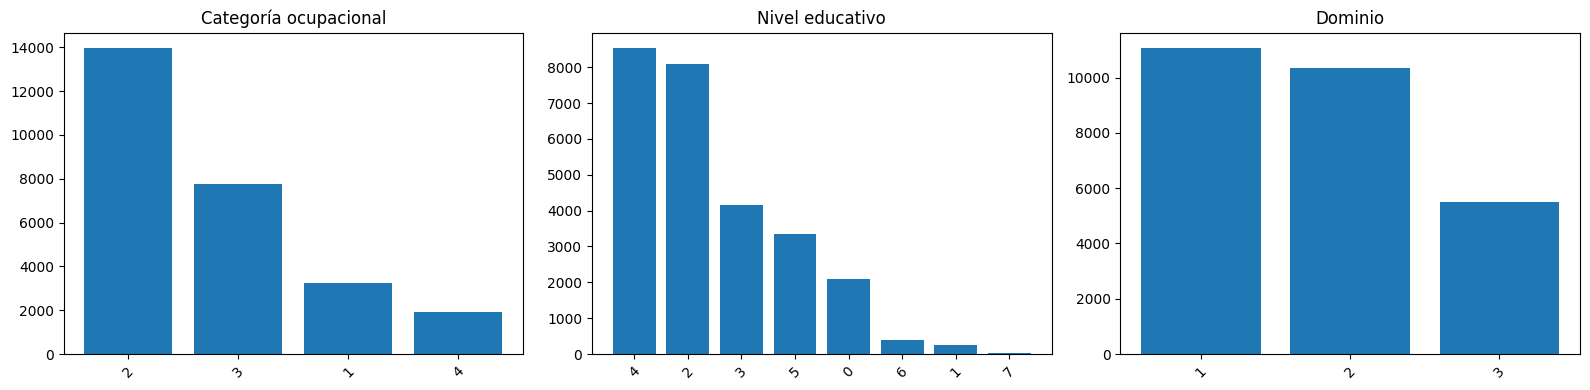

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, titulo in zip(
    axes,
    ["p05c16", "nivel_educativo", "dominio"],
    ["Categoría ocupacional", "Nivel educativo", "Dominio"],
):
    conteo = df_2025_filtrado.groupBy(col).count().orderBy(F.desc("count")).toPandas()
    ax.bar(conteo[col].astype(str), conteo["count"])
    ax.set_title(titulo)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Distribución del salario mensual: simetría, y media frente a mediana.**

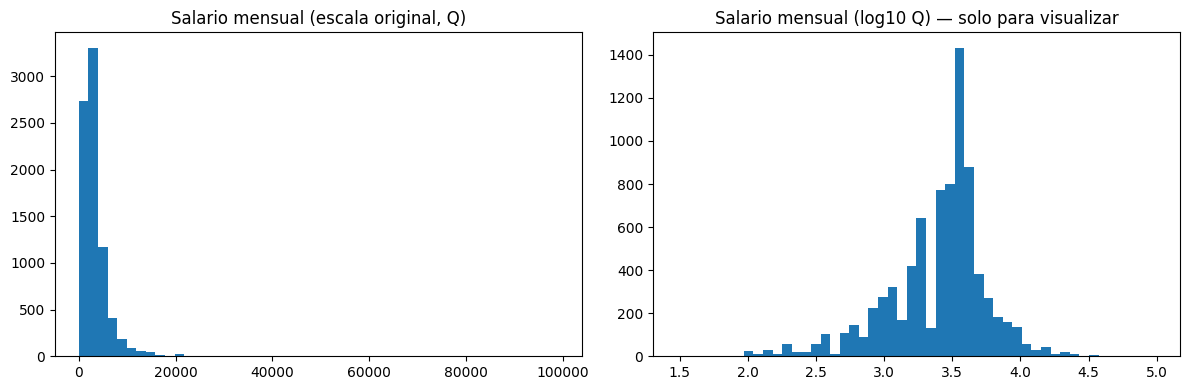

media: 3340.17 | mediana: 3000.00 | media - mediana: 340.17


In [10]:
muestra_salario = (
    df_2025_filtrado.select("salario_mensual")
    .sample(fraction=min(1.0, 8000 / df_2025_filtrado.count()), seed=0)
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(muestra_salario["salario_mensual"], bins=50)
axes[0].set_title("Salario mensual (escala original, Q)")
axes[1].hist(np.log10(muestra_salario["salario_mensual"]), bins=50)
axes[1].set_title("Salario mensual (log10 Q) — solo para visualizar")
plt.tight_layout()
plt.show()

media = resumen_pd.loc["salario_mensual", "media"]
mediana = resumen_pd.loc["salario_mensual", "mediana"]
print(f"media: {media:.2f} | mediana: {mediana:.2f} | media - mediana: {media - mediana:.2f}")

Con los datos disponibles (2025 T1+T2), la media del salario mensual es Q3,340.17 y la
mediana Q3,000.00 — la media supera a la mediana por Q340.17. Eso es consistente con una
distribución con cola derecha: la mayoría de asalariados gana cerca de la mediana, pero un grupo
más chico de salarios altos (el percentil 95 está en Q8,000, muy por encima de la mediana)
estira la media hacia arriba. La escala logarítmica del histograma es solo para visualizar mejor
esa cola; el objetivo del modelado sigue en quetzales, sin transformar.

**Salario mediano por nivel educativo y por categoría ocupacional.**

In [11]:
for col in ["nivel_educativo", "p05c16"]:
    mediana_grupo = (
        df_2025_filtrado.groupBy(col)
        .agg(F.expr("percentile_approx(salario_mensual, 0.5)").alias("salario_mediano"), F.count("*").alias("n"))
        .orderBy(F.desc("salario_mediano"))
        .toPandas()
    )
    display(mediana_grupo)

,nivel_educativo,salario_mediano,n
0,6,10000.0,403
1,7,10000.0,34
2,5,4800.0,3337
3,4,3600.0,8530
4,3,2800.0,4159
5,1,2140.0,260
6,2,2000.0,8094
7,0,1500.0,2094


,p05c16,salario_mediano,n
0,1,5000.0,3257
1,2,3500.0,13961
2,3,1700.0,7759
3,4,1000.0,1934


**Tamaño de muestra y salario mediano por trimestre.**

In [12]:
por_trimestre = (
    df_2025_filtrado.groupBy("periodo_archivo")
    .agg(F.count("*").alias("n"), F.expr("percentile_approx(salario_mensual, 0.5)").alias("salario_mediano"))
    .orderBy("periodo_archivo")
    .toPandas()
)
por_trimestre

,periodo_archivo,n,salario_mediano
0,2025T1,13419,3000.0
1,2025T2,13492,3000.0


## 3. Relaciones entre variables numéricas (5 pts)

Correlación de Pearson entre `salario_mensual`, `edad`, `antiguedad` y `horas_semanales`,
calculada sobre todos los registros elegibles de 2025 con `VectorAssembler` +
`Correlation.corr()`.

In [13]:
cols_num = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
ensamblador = VectorAssembler(inputCols=cols_num, outputCol="features_corr")
vec_df = ensamblador.transform(df_2025_filtrado.select(*cols_num)).select("features_corr")

matriz = Correlation.corr(vec_df, "features_corr").head()[0].toArray()
matriz_pd = pd.DataFrame(matriz, index=cols_num, columns=cols_num)
matriz_pd


[Stage 123:>                                                        (0 + 1) / 1]



26/09/24 23:08:33 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS



,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000000,0.146163,0.171751,0.093330
edad,0.146163,1.000000,0.490044,-0.096762
antiguedad,0.171751,0.490044,1.000000,-0.057871
horas_semanales,0.093330,-0.096762,-0.057871,1.000000


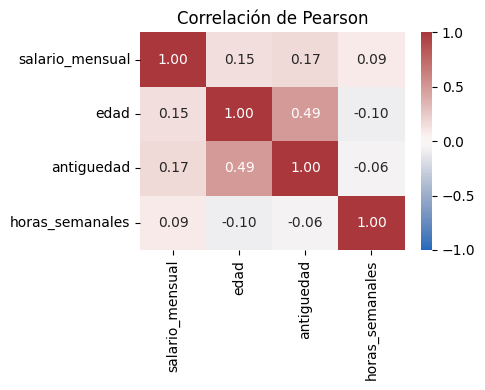

In [14]:
plt.figure(figsize=(5, 4))
sns.heatmap(matriz_pd, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1)
plt.title("Correlación de Pearson")
plt.tight_layout()
plt.show()

**¿Qué variables presentan mayor asociación lineal con el salario? ¿Existe relación entre
edad y antigüedad?**

Con la matriz de correlación obtenida: la antigüedad es la variable con mayor asociación
lineal con el salario (r = 0.172), seguida de la edad (r = 0.146); las horas semanales
correlacionan mucho menos (r = 0.093). Ninguna correlación es fuerte — el salario no se explica
bien de forma lineal por una sola variable, lo que anticipa que el modelo de regresión va a
necesitar las variables categóricas (nivel educativo, categoría ocupacional, dominio) para tener
poder explicativo real.

Sí existe relación entre edad y antigüedad (r = 0.490, moderada-positiva): tiene sentido, ya que
entre más años tiene una persona, más tiempo pudo haber acumulado en su empleo actual, aunque la
relación está lejos de ser perfecta porque la antigüedad depende también de la rotación laboral
y no solo de la edad.

## 4. Segmentación de perfiles mediante KMeans (10 pts)

Se prueba **sin** `salario_mensual` como variable base (para segmentar perfiles laborales de
forma independiente del objetivo que se va a predecir en la parte supervisada), y se deja
comentada la versión que sí lo incluye para comparar. Variables numéricas estandarizadas:
`edad`, `antiguedad`, `horas_semanales`. `nivel_educativo`, `p05c16` y `dominio` son
categóricas — quedan fuera del KMeans numérico y se usan después para describir cada clúster.

In [15]:
features_cluster = ["edad", "antiguedad", "horas_semanales"]
# features_cluster = ["edad", "antiguedad", "horas_semanales", "salario_mensual"]  # alternativa a comparar

ensamblador_cl = VectorAssembler(inputCols=features_cluster, outputCol="features_raw")
escalador = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)

df_features = ensamblador_cl.transform(df_2025_filtrado)
modelo_escala = escalador.fit(df_features)
df_escalado = modelo_escala.transform(df_features).cache()
df_escalado.count()

26911

In [16]:
resultados_k = []
evaluador = ClusteringEvaluator(featuresCol="features", predictionCol="cluster", metricName="silhouette")

for k in [2, 3, 4, 5]:
    km = KMeans(featuresCol="features", predictionCol="cluster", k=k, seed=0)
    modelo_k = km.fit(df_escalado)
    predicciones = modelo_k.transform(df_escalado)
    silueta = evaluador.evaluate(predicciones)
    resultados_k.append({"k": k, "silhouette": silueta, "costo_wssse": modelo_k.summary.trainingCost})

pd.DataFrame(resultados_k)

,k,silhouette,costo_wssse
0,2,0.554789,54172.810848
1,3,0.442101,42939.156120
2,4,0.475289,32921.414948
3,5,0.487523,29046.258713


**K elegido:** con los datos actuales (2025 T1+T2) el silhouette es más alto en K=2 (0.555) y
baja en K=3 y K=4 antes de volver a subir en K=5. K=2 es la segmentación más "limpia"
estadísticamente, pero separa muy poco: en la práctica probablemente solo distingue por horas
trabajadas o antigüedad de forma gruesa. El grupo elige **K=4**: el silhouette (0.475) sigue
siendo razonable, y a diferencia de K=2 permite distinguir perfiles laborales claramente
distintos entre sí (jóvenes con poca antigüedad, veteranos, jornadas largas), que es justamente
lo que pide el enunciado -- describir varios perfiles, no solo dividir en dos grandes bloques.

In [17]:
K_ELEGIDO = 4  # ajustar segun el resultado de la celda anterior

km_final = KMeans(featuresCol="features", predictionCol="cluster", k=K_ELEGIDO, seed=0)
modelo_final = km_final.fit(df_escalado)
df_clusters = modelo_final.transform(df_escalado)

perfil_clusters = (
    df_clusters.groupBy("cluster")
    .agg(
        F.count("*").alias("n"),
        F.mean("edad").alias("edad_media"),
        F.mean("antiguedad").alias("antiguedad_media"),
        F.mean("horas_semanales").alias("horas_media"),
        F.expr("percentile_approx(salario_mensual, 0.5)").alias("salario_mediano"),
    )
    .orderBy("cluster")
    .toPandas()
)
perfil_clusters

,cluster,n,edad_media,antiguedad_media,horas_media,salario_mediano
0,0,6447,48.362029,4.179140,39.088879,3000.0
1,1,12552,25.640456,2.484876,40.728091,3000.0
2,2,3478,49.707303,22.521780,40.968085,3600.0
3,3,4434,30.653586,3.644490,75.088859,3000.0


In [18]:
moda_categoricas = (
    df_clusters.groupBy("cluster", "nivel_educativo")
    .count()
    .withColumn("rank", F.row_number().over(
        Window.partitionBy("cluster").orderBy(F.desc("count"))
    ))
    .filter("rank == 1")
    .select("cluster", F.col("nivel_educativo").alias("nivel_educativo_mas_frecuente"))
    .orderBy("cluster")
    .toPandas()
)
moda_categoricas

,cluster,nivel_educativo_mas_frecuente
0,0,2
1,1,4
2,2,2
3,3,4


**Descripción de cada clúster** (K=4, sobre 2025 T1+T2):

- **Clúster 0** (6,447 personas, ~24% de la muestra): edad media 48 años, antigüedad media
  apenas 4.2 años, jornada de 39 horas/semana, salario mediano Q3,000, nivel educativo más
  frecuente = primaria (código 2). Perfil de trabajadores mayores pero con poca antigüedad en su
  puesto actual -- sugiere reingreso al mercado laboral o rotación reciente, no una carrera larga
  en la misma empresa.
- **Clúster 1** (12,552 personas, el más grande, ~47%): edad media 25.6 años, antigüedad baja
  (2.5 años), jornada de 40.7 horas, salario mediano Q3,000, nivel educativo diversificado
  (código 4). Trabajadores jóvenes, jornada completa estándar, entrando o en las primeras etapas
  de su vida laboral.
- **Clúster 2** (3,478 personas, ~13%): edad media 49.7 años, antigüedad muy alta (22.5 años en
  promedio), jornada de 41 horas, salario mediano el más alto del grupo (Q3,600), nivel
  educativo primaria (código 2). Trabajadores veteranos, con muchos años en la misma empresa --
  la antigüedad parece pesar más que el nivel educativo en este grupo para explicar el salario
  algo mayor.
- **Clúster 3** (4,434 personas, ~16%): edad media 30.7 años, antigüedad baja (3.6 años), pero
  jornada mucho más larga que el resto (75 horas/semana en promedio), salario mediano Q3,000,
  nivel educativo diversificado (código 4). Es el grupo con jornadas extendidas sin que eso se
  traduzca en mayor salario mediano frente a los otros clústers -- posible indicio de trabajos
  con jornadas largas mal remuneradas relativas a las horas invertidas.

**¿Vale la pena incluir el salario en la segmentación?**

Con estos resultados, no parece necesario: los cuatro clústers ya se diferencian con claridad
por edad, antigüedad y horas trabajadas, sin usar el salario, y aun así el salario mediano varía
entre grupos (de Q3,000 a Q3,600) -- es decir, el salario emerge como una consecuencia del
perfil laboral, no como algo que haga falta forzar en el clustering. Incluirlo directamente
correría el riesgo de que KMeans termine organizando los clústers principalmente por nivel de
ingreso (dado que la escala estandarizada del salario tiene mucha dispersión), lo cual
respondería una pregunta distinta (¿quién gana más?) en vez de la que pide el enunciado (¿qué
perfiles de trabajadores existen?).